# 第055讲 不平衡与有偏标签

把概率、决策与标注机制分开。所有计算从当前数据重跑，不粘贴旧结果。完整推导、条件和参考见lecture.pdf、lab.pdf、sources.md。

## 1 数据与预测时点
2000训练、1200验证、4000自然测试。观察开关和噪声标签只作用于训练。

In [1]:
import json,numpy as np
from IPython.display import display,Image
import experiment as e
data=np.load(e.ROOT/'data/draws.npz')
print(data['X0'].shape,data['y0'].shape)
print(json.loads((e.ROOT/'data/protocol.json').read_text()))

(7200, 4) (7200,)
{'seeds': [5500, 5501, 5502, 5503, 5504, 5505], 'population_prior': 0.08, 'n_train': 2000, 'n_validation': 1200, 'n_test': 4000, 'features': 4, 'class1_mean': [1.4, 0.8, 0, 0], 'class0_mean': [0, 0, 0, 0], 'covariance': 'identity', 'cost_false_negative': 8.0, 'cost_false_positive': 1.0, 'threshold_grid': [0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.06999999999999999, 0.08, 0.09, 0.09999999999999999, 0.11, 0.12, 0.13, 0.14, 0.15000000000000002, 0.16, 0.17, 0.18000000000000002, 0.19, 0.2, 0.21000000000000002, 0.22, 0.23, 0.24000000000000002, 0.25, 0.26, 0.27, 0.28, 0.29000000000000004, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36000000000000004, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42000000000000004, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48000000000000004, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.5800000000000001, 0.59, 0.6], 'correction_target_prior': 'training sample prevalence estimate; not test labels

## 2 纸笔公式的代码核验
成本阈值1/9；原概率0.1加九倍正权重后变0.5；先验修正可反向恢复。

In [2]:
print('cost threshold',1/(1+8))
print('weighted q',(9*.1)/(9*.1+1*.9))
print('corrected p',e.prior_correct(np.array([.5]),.5,.1))
print('Wilson16/20',e.wilson(16,20))
print('noisy q at p=.1',.02+.73*.1)

cost threshold 0.1111111111111111
weighted q 0.5
corrected p [0.1]
Wilson16/20 [0.5839825677481064, 0.919342337420202]
noisy q at p=.1 0.093


## 3 真实运行所有路线
新拟合42个LogisticRegression模型；多个阈值路线复用同一自然模型，oracle使用已知生成式。

In [3]:
result=e.run()
e.dump(result,e.ROOT/'outputs/notebook-result.json')
print(json.dumps({'main':result['summary'],'labels':result['label_summary']},ensure_ascii=False,indent=2))

{
  "main": {
    "natural_05": {
      "recall": 0.22790860317719738,
      "precision": 0.6626986299865353,
      "accuracy": 0.9300833333333333,
      "cost_per_case": 0.49545833333333333,
      "brier": 0.05503510230913944,
      "average_precision": 0.46076679541945004,
      "roc_auc": 0.864840946331762,
      "mean_probability": 0.07820369573666348
    },
    "natural_cost": {
      "recall": 0.7039311835821964,
      "precision": 0.287739335993419,
      "accuracy": 0.8392499999999999,
      "cost_per_case": 0.32408333333333333,
      "brier": 0.05503510230913944,
      "average_precision": 0.46076679541945004,
      "roc_auc": 0.864840946331762,
      "mean_probability": 0.07820369573666348
    },
    "natural_tuned": {
      "recall": 0.6907413376626913,
      "precision": 0.2932415625230293,
      "accuracy": 0.8390833333333334,
      "cost_per_case": 0.33095833333333335,
      "brier": 0.05503510230913944,
      "average_precision": 0.46076679541945004,
      "roc_auc": 0.8

## 4 检查复制来源和计数
复制不创造新独立样本。测试正例数自然波动。

In [4]:
s=result['runs'][0]
ids=np.array(s['oversample_source_ids'])
print('train/validation/test positives',s['training_positives'],s['validation_positives'],s['test_positives'])
print('resample length, unique, min, max',len(ids),len(np.unique(ids)),ids.min(),ids.max())
for m in ['natural_05','natural_cost','natural_tuned']:
    print(m,s['methods'][m]['metrics'])

train/validation/test positives 151 105 326
resample length, unique, min, max 3698 2000 0 1999
natural_05 {'threshold': 0.5, 'tp': 76, 'fn': 250, 'fp': 43, 'tn': 3631, 'n': 4000, 'positives': 326, 'recall': 0.2331288343558282, 'recall_wilson95': [0.1905007459549959, 0.28197308852865355], 'precision': 0.6386554621848739, 'accuracy': 0.92675, 'cost_per_case': 0.51075, 'brier': 0.05765080485574697, 'average_precision': 0.44091869508973336, 'roc_auc': 0.8632381082787018, 'mean_probability': 0.08052951060791204, 'prevalence': 0.0815}
natural_cost {'threshold': 0.1111111111111111, 'tp': 229, 'fn': 97, 'fp': 541, 'tn': 3133, 'n': 4000, 'positives': 326, 'recall': 0.7024539877300614, 'recall_wilson95': [0.6507018301921959, 0.7494904333029666], 'precision': 0.2974025974025974, 'accuracy': 0.8405, 'cost_per_case': 0.32925, 'brier': 0.05765080485574697, 'average_precision': 0.44091869508973336, 'roc_auc': 0.8632381082787018, 'mean_probability': 0.08052951060791204, 'prevalence': 0.0815}
natural_t

## 5 从验证预测重算阈值
这里使用2000:3200的验证y，不传入测试y。

In [5]:
threshold,trials=e.choose_threshold(data['y0'][2000:3200],np.array(s['validation_probability']))
print('selected threshold',threshold)
print('best validation records',sorted(trials,key=lambda z:(z['cost'],z['threshold']))[:5])

selected threshold 0.09
best validation records [{'threshold': 0.09, 'cost': 0.37416666666666665}, {'threshold': 0.13, 'cost': 0.37583333333333335}, {'threshold': 0.16, 'cost': 0.37833333333333335}, {'threshold': 0.14, 'cost': 0.37916666666666665}, {'threshold': 0.08, 'cost': 0.38083333333333336}]


## 6 独立指标审计
另一套计数循环和Wilson公式核对72组记录、复制来源及概率前向。

In [6]:
import audit
checks=audit.audit(result)
e.dump(checks,e.ROOT/'outputs/notebook-audit.json')
print(checks)

{'status': 'passed', 'metric_records_independently_checked': 72, 'checks': ['confusion matrix', 'cost', 'Brier', 'Wilson recall interval', 'stored coefficient logits', 'validation-only threshold ledger', 'training-only resample IDs', 'prior correction', 'observation IDs', 'absent minority and invalid inputs'], 'limits': ['oracle propensities known only in simulation', 'Wilson conditions on fixed classifier and observed positive count', 'no guarantee correction repairs arbitrary covariate or concept shift']}


## 7 由本次结果重建图
原始加权概率在自然分布中会有不同含义；图5区间不是重新训练的不确定性。

In [7]:
import plots
paths=plots.draw(result,e.ROOT/'outputs/notebook-figures')
print([p.name for p in paths])

['01_protocol.png', '02_decisions.png', '03_threshold.png', '04_correction.png', '05_minority_intervals.png', '06_biased_labels.png', '07_reliability.png']


自然测试的边界

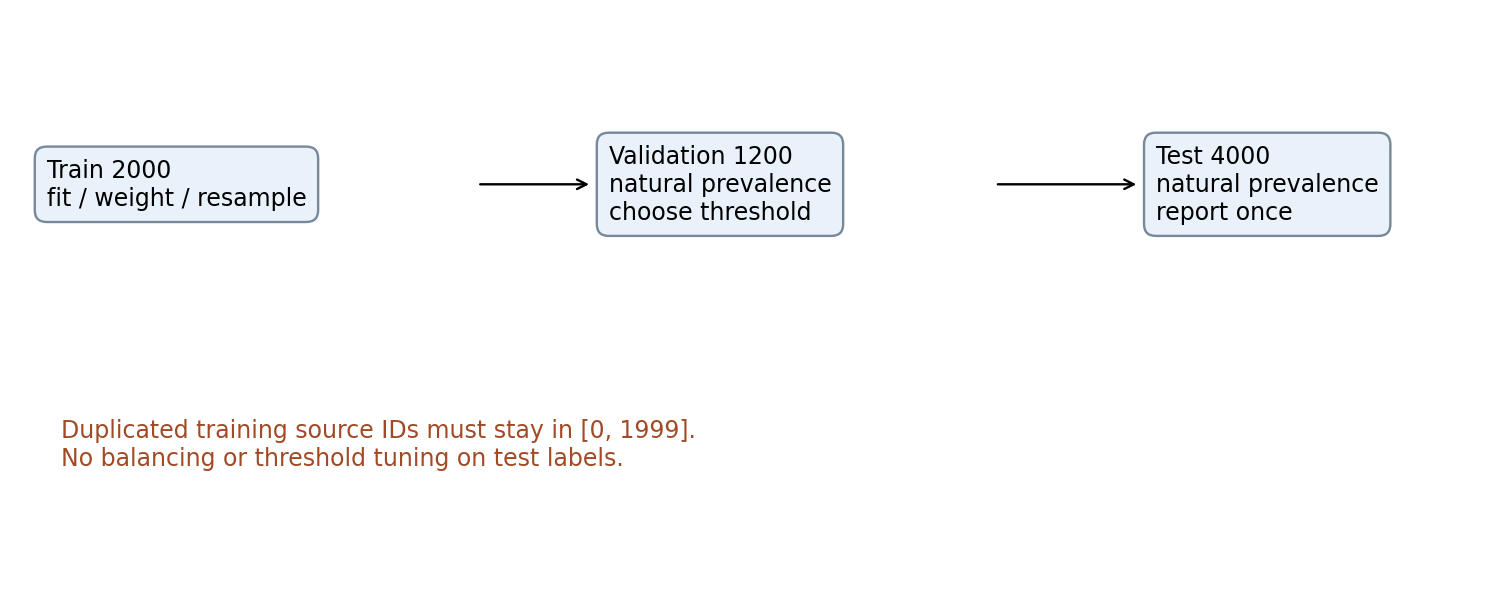

In [8]:
display(Image(filename=str(paths[0])))

召回与成本

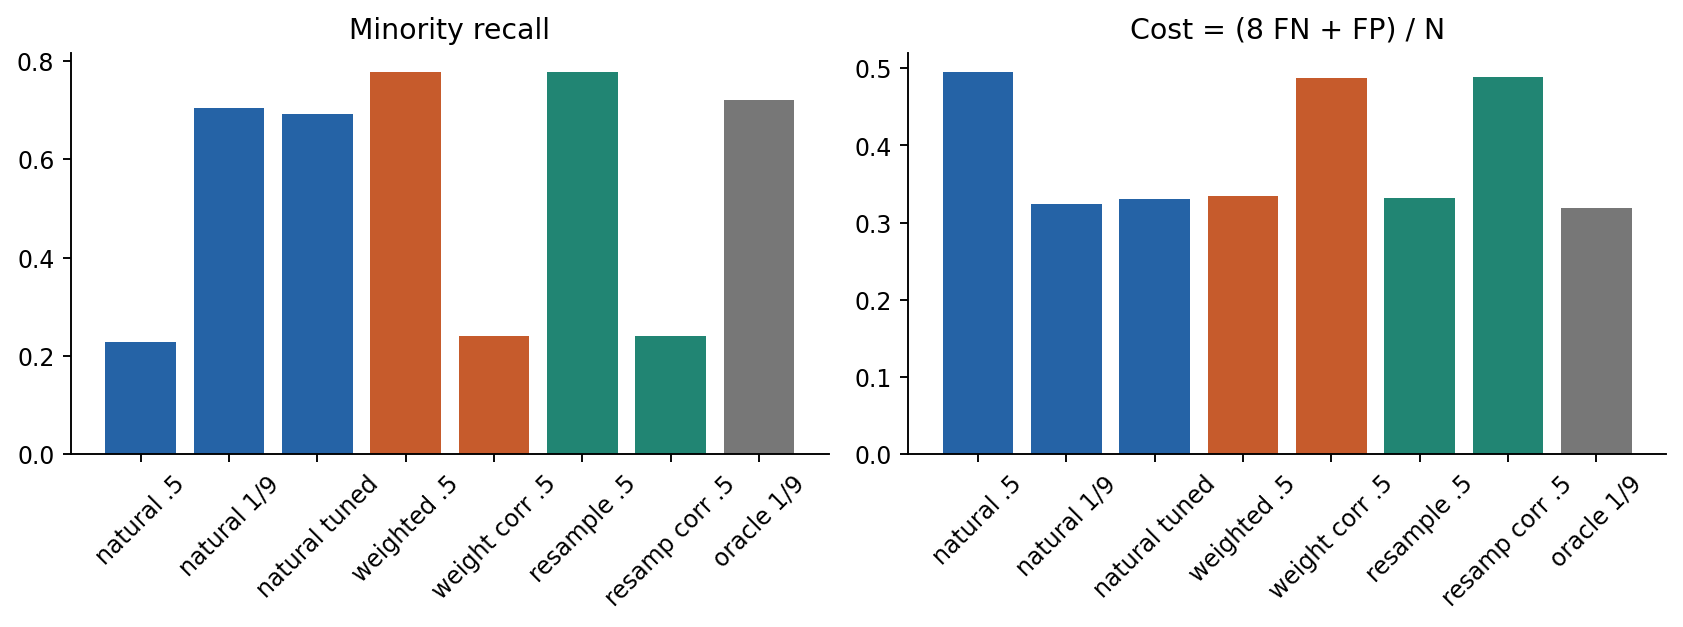

In [9]:
display(Image(filename=str(paths[1])))

验证阈值曲线

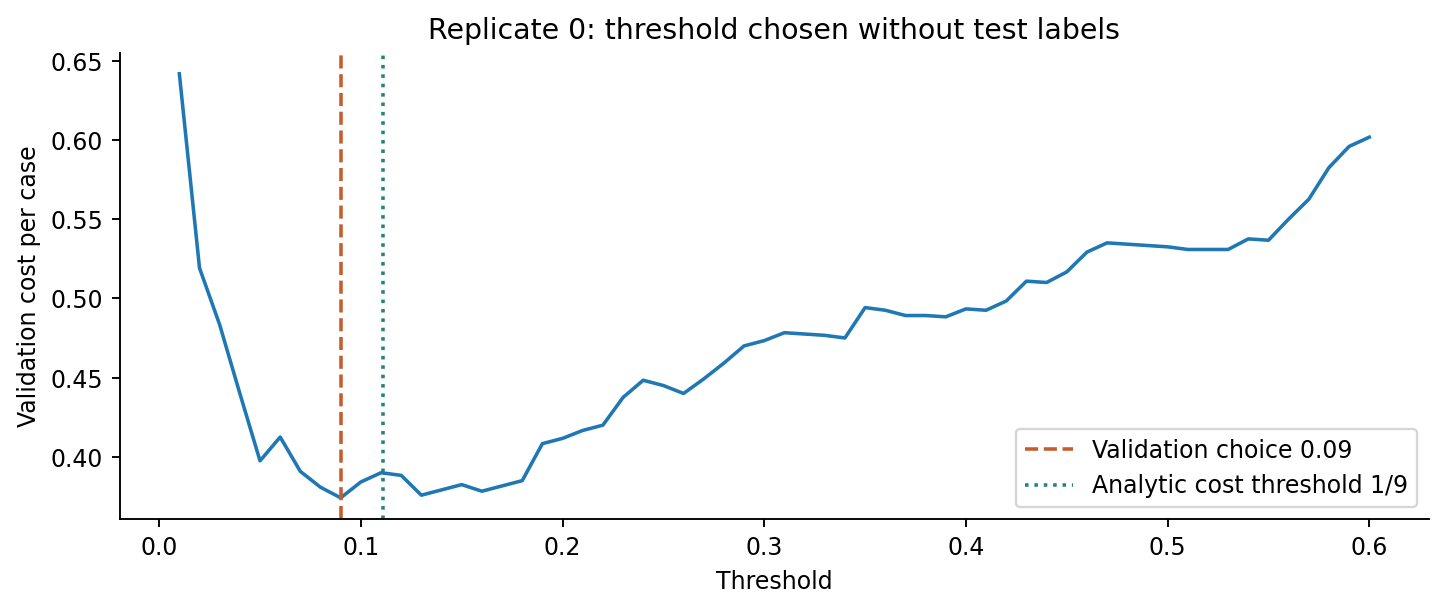

In [10]:
display(Image(filename=str(paths[2])))

先验修正与Brier

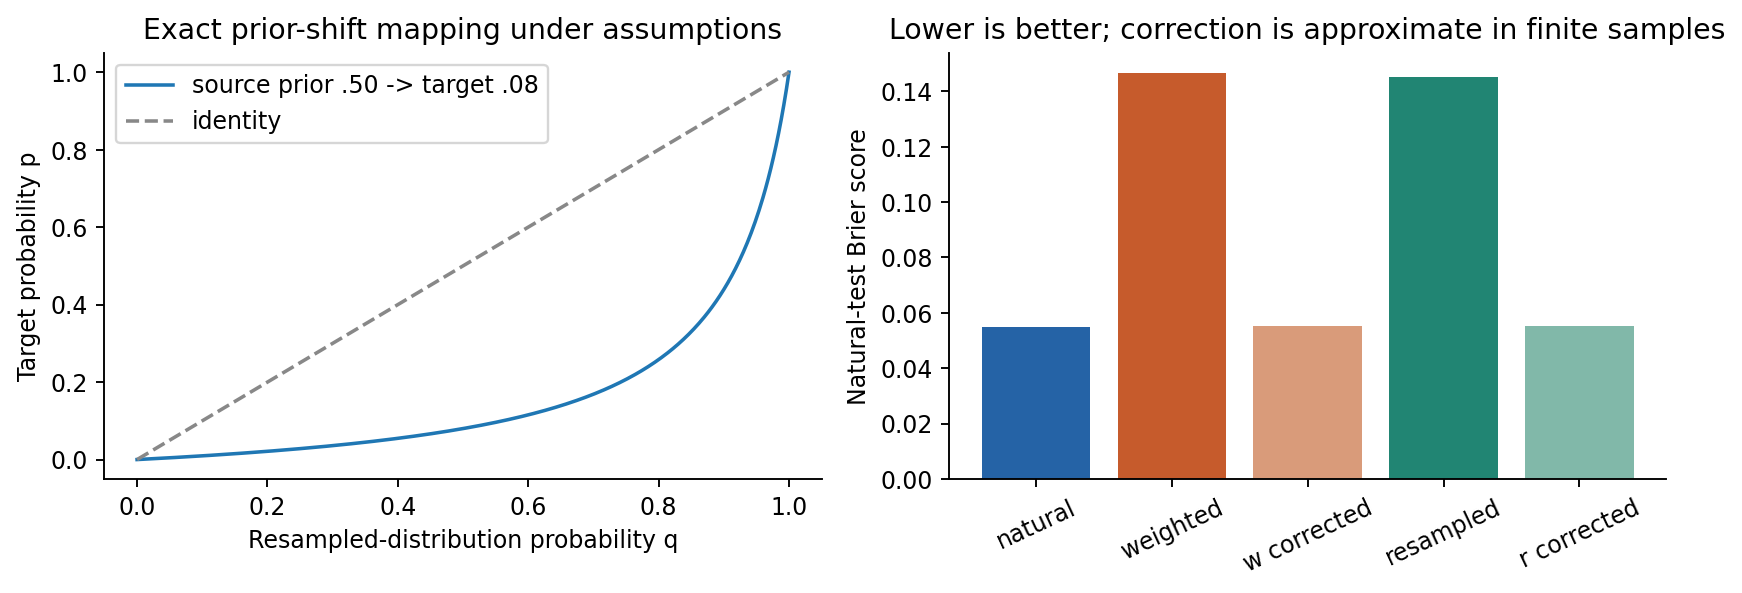

In [11]:
display(Image(filename=str(paths[3])))

少数类Wilson区间

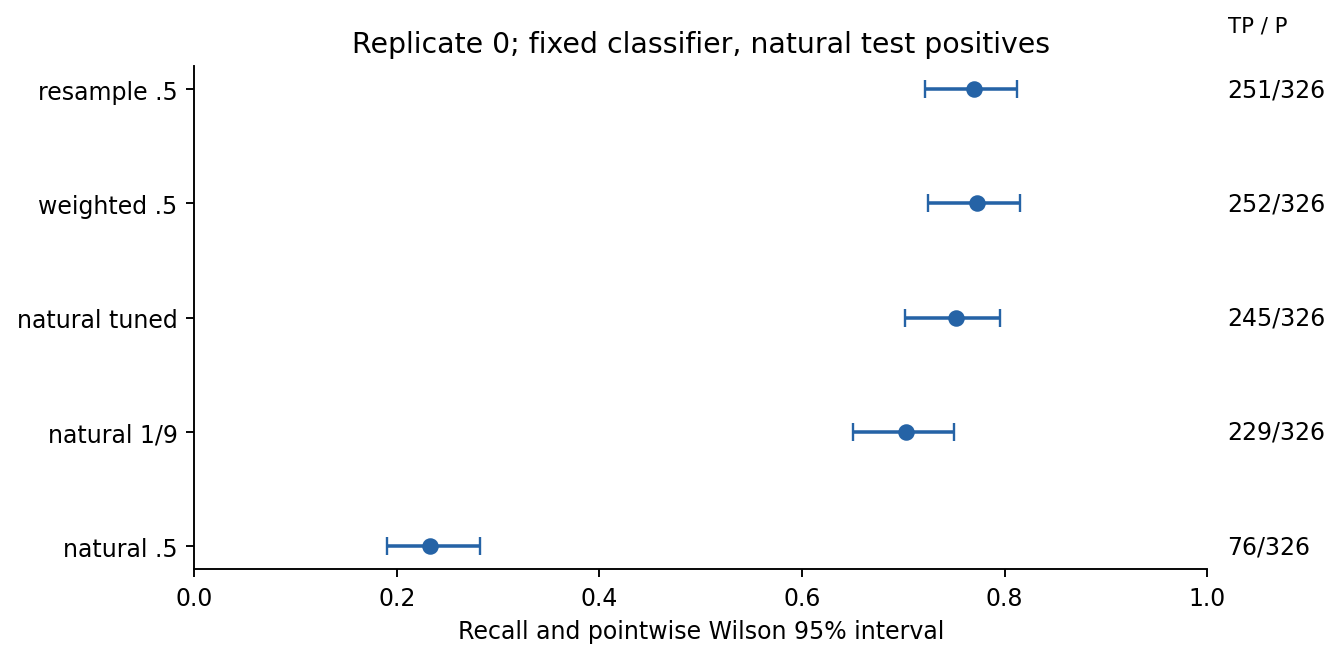

In [12]:
display(Image(filename=str(paths[4])))

有偏标签对照

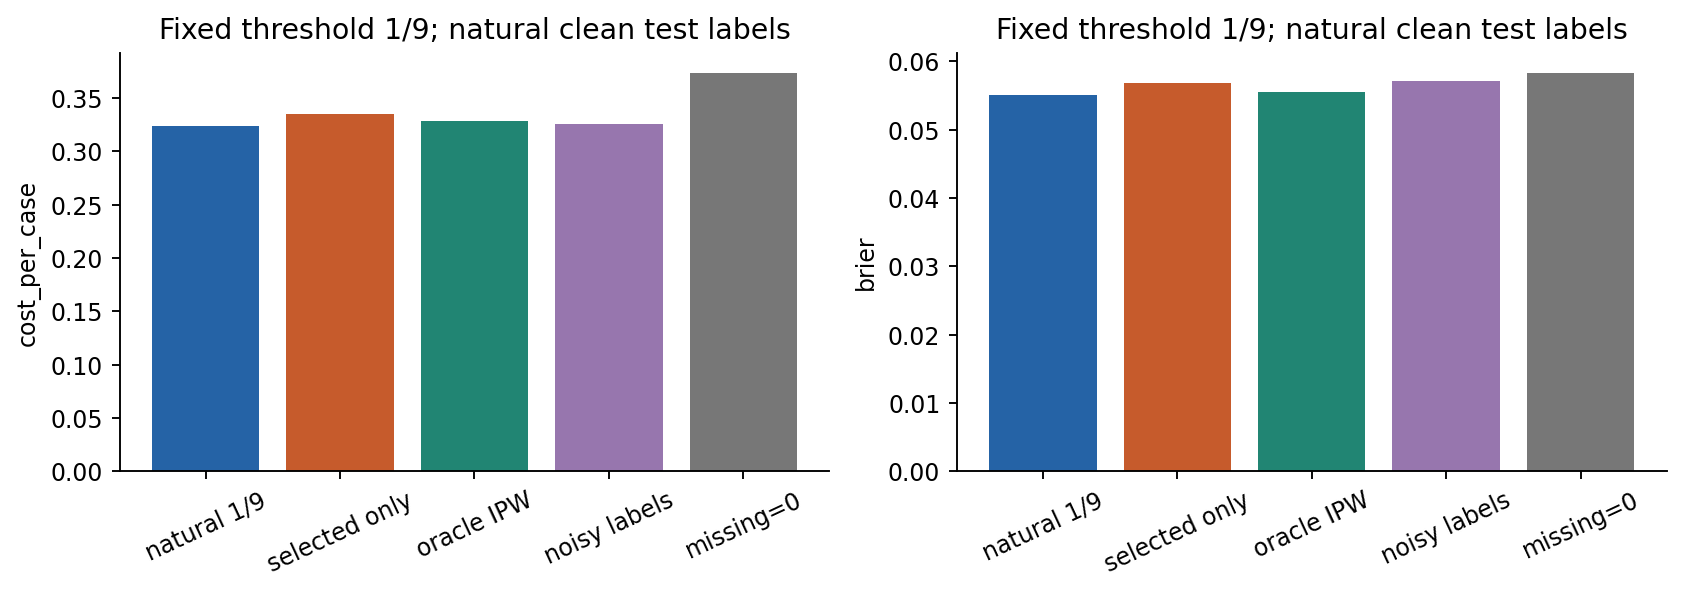

In [13]:
display(Image(filename=str(paths[5])))

分箱可靠性图

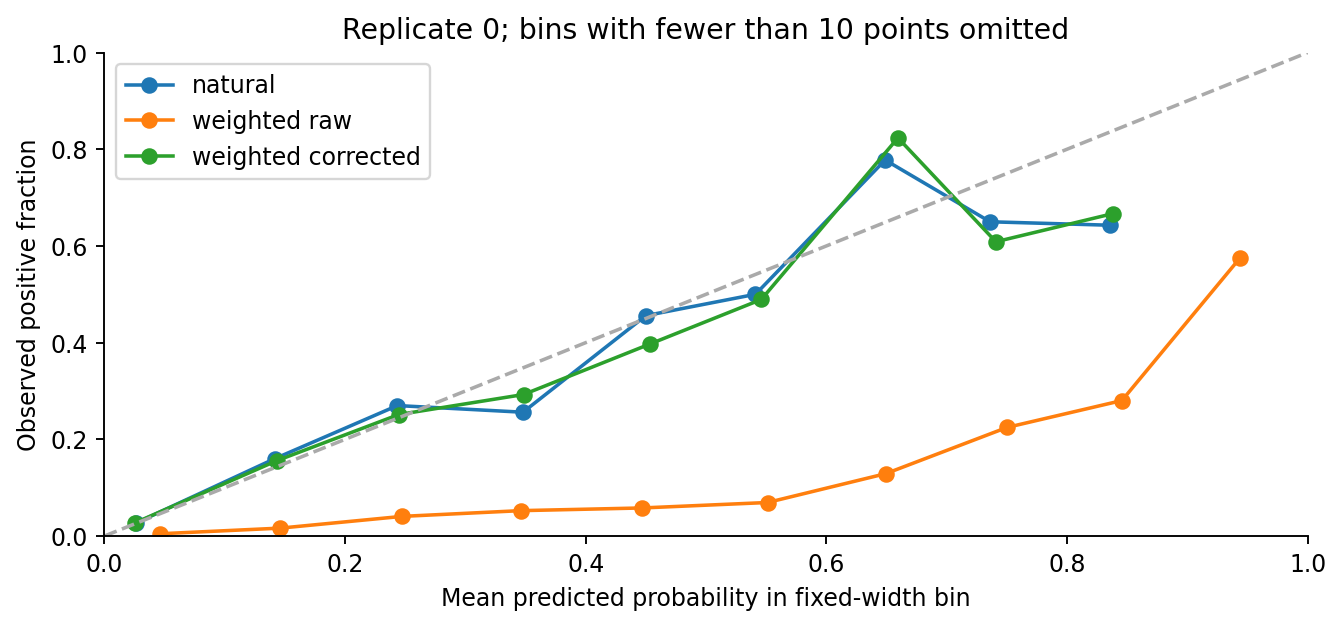

In [14]:
display(Image(filename=str(paths[6])))

## 8 写出不能下的结论
为什么验证阈值没胜出仍是有效结果？为什么oracle IPW不能证明现实选择机制已可识别？为什么修正概率后还要考虑决策阈值？先答再读answers.pdf。